NetID: leahnl2

Assignment: Lab 7

Grade: _ / 6

Comments:


# CS448 - Lab 7: Pitch tracking and modifications

## Part 1: Making a pitch tracker

In this section we will design a pitch tracker. We will apply it on this sound file:

[https://drive.google.com/uc?export=download&id=1gB1MlHQJiXRJRYAauWxdJDcRoYs8q0oM ]

We want to find the pitch of the singing over time, as well as if the sound is pitched or not at any point in time. To do so we will design an autocorrelation pitch tracker.
Do the following:
1. Perform an STFT of the sound
2. Using the DFT representation of each frame compute the frame’s autocorrelation
3. Invert each frame’s autocorrelation back to the time domain
4. Find the first peak after the main peak (the main peak will be at address 0)
    - We will only look for pitches between 100 and 300Hz
	- Which means that you only need to look for a peak at a specific range
5. If the peak is more than 70% of the main peak we have a pitched frame
	- Otherwise it is an un-pitched frame
	
Plot the pitch value over time and see if it correlates with what you are hearing (we also have the correct plot in the lecture slides).


In [2]:
import utils
import numpy as np
import matplotlib.pyplot as plt
import scipy

Sound (Original),Your browser does not support the audio element.


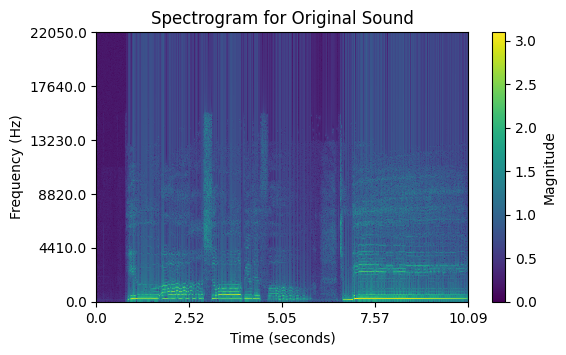

In [3]:
# YOUR CODE HERE

# read in sound file
singing_sr, singing_x = utils.wavreadfile("./data/beauty.wav")
utils.sound(singing_x, singing_sr, "Sound (Original)")

# perform STFT
dft_size = 1024
hop_size = dft_size // 4
stft = utils.stft(singing_x, dft_size, hop_size, window=None, padding=0)

# plot the spectrogram
plt.figure(figsize=(6, 3.5))
utils.plot_spectrogram(stft, dft_size, hop_size, singing_sr, "Original")
plt.show()

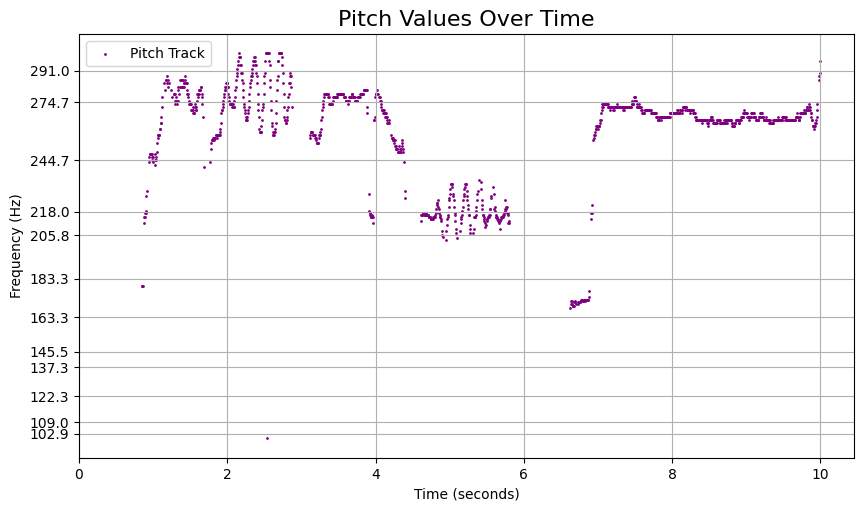

In [4]:
def pitch_track(stft, sample_rate):
    # calculate the pitch bin cutoffs (frequency -> period, where f = 1 / T)
    pitch_100 = int(sample_rate / 100) # 100 Hz
    pitch_300 = int(sample_rate / 300) # 300 Hz
    
    # go through each frame in the sound's STFT
    num_frames = stft.shape[1]
    pitched_values = np.zeros(num_frames)
    unpitched_values = np.zeros(num_frames)
    
    for i in range(num_frames):
        # get current frame
        frame = stft[:, i]
        
        # compute the autocorrelation of the frame
        auto_corr = np.fft.irfft(frame * np.conj(frame))
    
        # get main peak
        main_peak = auto_corr[0]
    
        # find first peak after main peak in correct range (100-300Hz)
        search_region = auto_corr[pitch_300:pitch_100]
        peak_idx = np.argmax(search_region) + pitch_300
        next_peak = auto_corr[peak_idx]
    
        # determine whether frame is pitched or unpitched
        if next_peak > (0.7 * main_peak):
            pitched_values[i] = sample_rate / peak_idx
            unpitched_values[i] = np.nan
        else:
            unpitched_values[i] = sample_rate / peak_idx
            pitched_values[i] = np.nan
    
        # for debugging
        # if i == 250:
        #     plt.figure(figsize=(10, 4))
        #     plt.subplot(1, 2, 1)
        #     plt.plot(auto_corr)
        #     plt.plot(0, main_peak, 'ro')
        #     plt.plot(peak_idx, next_peak, 'bo')
        #     plt.title(f'Autocorrelation of Frame')
        #     plt.xlabel('Bin')
        #     plt.ylabel('Autocorrelation')
        #     plt.show()
    
    # plot the pitched values over time
    x_ticks = [0, 2, 4, 6, 8, 10]
    y_ticks = [102.9, 109.0, 122.3, 137.3, 145.5, 163.3, 183.3, 205.8, 218.0, 244.7, 274.7, 291.0]
    
    plt.figure(figsize=(10, 5.5))
    plt.scatter(np.arange(num_frames), pitched_values, color="purple", label="Pitch Track", marker="o", s=1)
    # plt.scatter(np.arange(num_frames), unpitched_values, color="orange", label="Unpitched Frames", marker="o", s=1)
    plt.xticks(ticks=np.linspace(0, num_frames, len(x_ticks)), labels=x_ticks)
    plt.yticks(ticks=y_ticks, labels=y_ticks) 
    plt.xlabel('Time (seconds)')
    plt.ylabel('Frequency (Hz)')
    plt.title('Pitch Values Over Time', fontsize=16)
    plt.legend()
    plt.grid()
    plt.show()

pitch_track(stft, singing_sr)

## Part 2. Changing pitch 

We will now correct the pitch of that last horrible note. We will use the zero crossing method to find where the periods are and then we will shift them appropriately to create a pitch of 274Hz.

1. Get samples 303,000 to 445,000 which is the horrible part.

2. Lowpass filter to facilitate the zero crossing finding

    - Pick an appropriate cutoff frequency that will help
    – Use the ```scipy.signal.filtfilt()``` function which will not time-shift the input
    
3. Find the zero crossing points which should be the start of each period

4. For each period get the signal from the previous period’s start till this period’s end

5. Window that signal with a Hann window to remove any discontinuities

6. Overlap add each of the above at a rate appropriate for 274Hz

Play the sound, does it sound more in tune? (it better!)

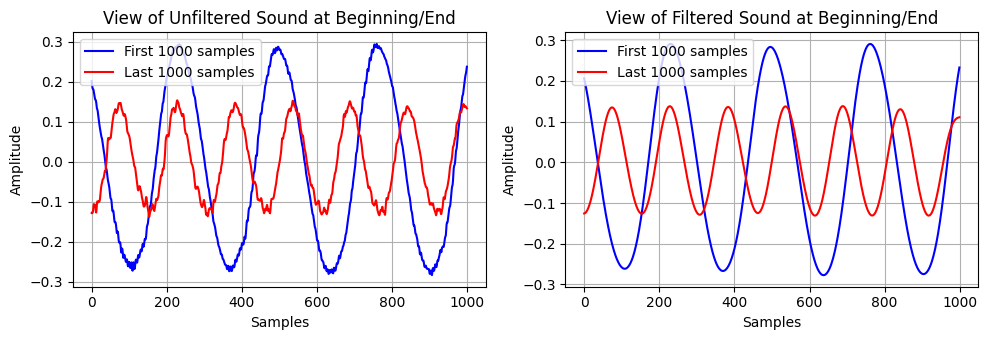

Bad Note,Your browser does not support the audio element.


Corrected Note,Your browser does not support the audio element.


Fixed Singing,Your browser does not support the audio element.


In [25]:
# YOUR CODE HERE

# define intended pitch
target_pitch = 274

# get bad part of singing
bad_pitch = singing_x[303000:445001]

# lowpass filter the bad sound for finding zero crossings
nyquist = singing_sr / 2
b, a = scipy.signal.butter(4, (target_pitch * 2) / nyquist, btype='low')
filtered_pitch = scipy.signal.filtfilt(b, a, bad_pitch)

# visualize small portion of filtered sound at beginning and end (sanity check)
plt.figure(figsize=(10, 3.5))

beginning_portion = bad_pitch[:1000]
end_portion = bad_pitch[-1000:]

plt.subplot(1, 2, 1)
plt.plot(beginning_portion, color="blue", label="First 1000 samples")
plt.plot(end_portion, color='red', label="Last 1000 samples")
plt.title("View of Unfiltered Sound at Beginning/End")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

beginning_portion = filtered_pitch[:1000]
end_portion = filtered_pitch[-1000:]

plt.subplot(1, 2, 2)
plt.plot(beginning_portion, color="blue", label="First 1000 samples")
plt.plot(end_portion, color='red', label="Last 1000 samples")
plt.title("View of Filtered Sound at Beginning/End")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# find zero-crossings (rising edges only for start of each period)
zero_crossings = []
for i in range(len(filtered_pitch) - 1):
    if filtered_pitch[i] < 0 and filtered_pitch[i + 1] > 0:
        zero_crossings.append(i)

# get the winowed signals from the previous period’s start till this period’s end
period_signals = []
for i in range(1, len(zero_crossings) - 1):
    prev_start, curr_end = zero_crossings[i-1], zero_crossings[i+1]
    signal = bad_pitch[prev_start:curr_end] * np.hanning(curr_end - prev_start)

    # window the signal before appending
    period_signals.append(signal)

# overlap add the period signals at a rate appropriate for 274Hz
corrected_pitch = np.zeros_like(bad_pitch)
step_size = int(singing_sr / target_pitch) # target period in number of samples

start_idx = 0
for period_signal in period_signals:
    end_idx = start_idx + len(period_signal)
    
    if end_idx >= len(new_signal):
        break
    
    corrected_pitch[start_idx:end_idx] += (0.5 * period_signal)
    start_idx += step_size

# play the bad and corrected note
utils.sound(bad_pitch, singing_sr, "Bad Note")
utils.sound(corrected_pitch, singing_sr, "Corrected Note")

# add corrected note back into original singing
corrected_singing_x = singing_x.copy()
corrected_singing_x[303000:445001] = corrected_pitch
utils.sound(corrected_singing_x, singing_sr, "Fixed Singing")

I plotted the waveform after lowpass filtering it in order to make sure it wasn't too aggressive. To visualize, I took the first and last 1000 samples, which allowed me to see whether the excess wiggling in the waveform was removed. I also wanted to make sure that the waveform wasn't tapering off (as shown in the lecture slides).